In [1]:
# 必要なパッケージを呼び出す
using NLsolve
using Plots
using Roots

In [2]:
# MATLABではグローバル変数を使って関数への変数受け渡しを行う
# Julia/Pythonではコンストラクタを用いる

# ギリシャ文字の使用は不可とする
struct Model{TI<:Integer, TF<:AbstractFloat}

    # カリブレーション
    alpha::TF 
    beta::TF           
    delta::TF 
    Abar::TF

    # 定常状態の値
    kss::TF
    css::TF    
    
    # 移行過程に関する変数
    T::TI

end

In [3]:
# カリブレーション
alpha = 0.4; 
beta = 0.96;
delta = 1.0; 
Abar = 1.0;

# 定常状態の値
kss = (alpha*beta*Abar/(1-beta*(1-delta)))^(1/(1-alpha));
css = Abar*kss^alpha - delta*kss;

# 移行過程に関する変数
T = 100; 

# k の初期値
k0 = 0.1*kss; 

##### 後ろ向き帰納法によって移行経路を解く(transition2.m に対応)

In [4]:
m = Model(alpha,beta,delta,Abar,kss,css,T);

# imaginary states
kvec0 = collect(range(k0,m.kss,m.T));
kvec1 = copy(kvec0);
yvec = zeros(m.T);
rvec = zeros(m.T);
wvec = zeros(m.T);
cvec = zeros(m.T);
kvec = zeros(m.T);

lamk = 0.9;
diff = 1e+4;
crit = 1e-4;
iter = 0;

while diff > crit

    yvec .= m.Abar .* (kvec0 .^ m.alpha);
    rvec .= m.alpha .* yvec./kvec0;
    wvec .= (1-m.alpha) .* yvec;
    
    cvec[m.T] = css;
    for i in T-1:-1:1 # t=T-1,...,1,0
        cvec[i] = cvec[i+1]/(beta*(1+rvec[i+1]-delta));
    end

    kvec[1] = k0;
    for j in 1:T-1
        kvec[j+1] = yvec[j] - cvec[j] + (1-m.delta)*kvec[j]; # k1,k2,...,kT
    end

    # update
    kvec1 = lamk*kvec0 + (1-lamk)*kvec;

    diff = maximum(abs.(kvec1-kvec0));
    kvec0 = copy(kvec1);
    iter += 1;

    # use the terminal condition as the criterion
    println([iter, diff])
    flush(stdout)
end

[1.0, 0.030751717589878352]
[2.0, 0.030881088034550308]
[3.0, 0.030696004174300878]
[4.0, 0.03043485631161033]
[5.0, 0.0304372208476984]
[6.0, 0.02328467940886844]
[7.0, 0.02743942355522644]
[8.0, 0.027487768525698703]
[9.0, 0.02430725855220378]
[10.0, 0.01774361613707419]
[11.0, 0.09065670158000315]
[12.0, 0.050097795668266665]
[13.0, 0.029087412780750194]
[14.0, 0.02806016260691621]
[15.0, 0.02647738712798553]
[16.0, 0.02089692241734495]
[17.0, 0.016143808924757974]
[18.0, 0.051165593171118184]
[19.0, 0.040965985661096355]
[20.0, 0.028387036800989418]
[21.0, 0.020922196147446975]
[22.0, 0.0226784222515381]
[23.0, 0.021157188553934475]
[24.0, 0.01778588927960781]
[25.0, 0.014570711988680957]
[26.0, 0.023533849904150805]
[27.0, 0.03135004046604992]
[28.0, 0.02627017907544335]
[29.0, 0.020107660862766136]
[30.0, 0.01563152320542452]
[31.0, 0.01620501281576564]
[32.0, 0.016596554095543226]
[33.0, 0.015006759258535035]
[34.0, 0.012674892496211315]
[35.0, 0.010652900265492704]
[36.0, 0.013

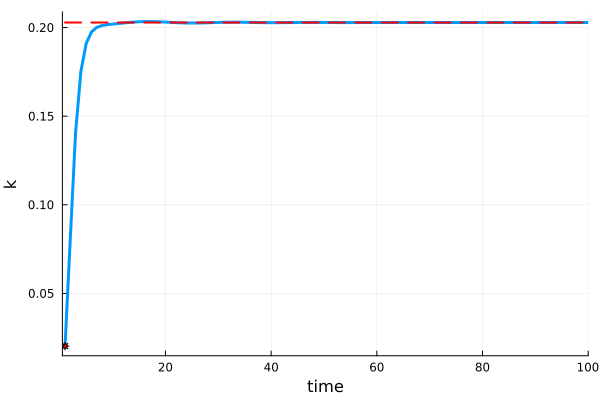

In [5]:
plot(kvec[1:T],legend=false,lw=3)
scatter!([1.0],[kvec[1]],c=:red,markershape=:star8)
plot!([1,100],[m.kss,m.kss],c=:red,ls=:dash,lw=2)
xlabel!("time")
ylabel!("k")
xlims!(0.5,m.T)

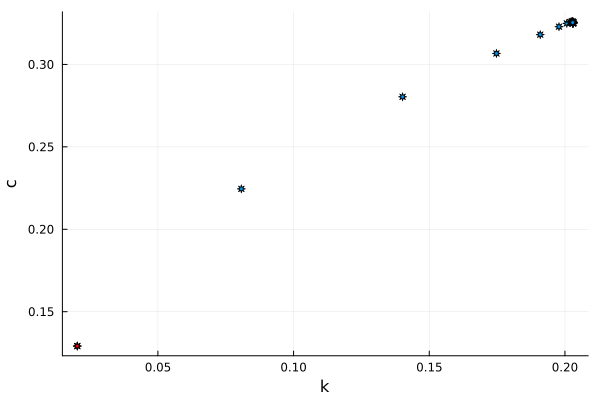

In [6]:
scatter(kvec0,cvec,markershape=:star8,legend=false)
scatter!([kvec0[1]],[cvec[1]],markershape=:star8,c=:red)
xlabel!("k")
ylabel!("c")

In [7]:
m = Model(alpha,beta,delta,Abar,kss,css,T);

# imaginary states
kvec0 = collect(range(k0,m.kss,m.T));
kvec1 = copy(kvec0);
yvec = zeros(m.T);
rvec = zeros(m.T);
wvec = zeros(m.T);
cvec = zeros(m.T);
kvec = zeros(m.T);

lamk = 0.9;
diff = 1e+4;
crit = 1e-4;
iter = 0;

In [8]:
function shooting(m,x,k0)
    """
    ------------------------------------------------------
    === ためし打ち法において、消費と資本の流列を求める関数 ===
    ------------------------------------------------------
    <input>
    ・m: パラメータ等を含む構造体
    ・x: 消費の初期値(求根問題のためにベクトル表記する)
    ・k0: 資本の初期値
    <output>
    ・k: 資本の流列
    ・c: 消費の流列
    """
    
    c0 = x[1];
    k = zeros(m.T+1);
    c = zeros(m.T+1);

    k[1] = k0;
    c[1] = c0;

    for t in 1:m.T

        k[t+1] = max(m.Abar*(k[t]^m.alpha) + (1-m.delta)*k[t] - c[t], 1e-4); # k>0
        c[t+1] = m.beta*c[t]*(1 + m.Abar*m.alpha*(k[t+1]^(m.alpha-1)) - m.delta);

    end

    return k, c
end

function shooting_err(m,x,k0)
    """
    --------------------------------------------------------------
    === ためし打ち法において、資本の定常状態とk_{T}の差を求める関数 ===
    --------------------------------------------------------------
    <input>
    ・m: パラメータ等を含む構造体
    ・x: 消費の初期値(求根問題のためにベクトル表記する)
    ・k0: 資本の初期値
    <output>
    ・err: 資本の定常状態とk_{T}の差
    """

    k, c = shooting(m,x,k0);
    err = k[m.T+1] - m.kss;

    return err
end

shooting_err (generic function with 1 method)

In [9]:
c0 = find_zero(x->shooting_err(m,x,k0),(0.0,10.0));
k,c = shooting(m,[c0],k0);

In [10]:
k0_list = k0:0.002:0.26;
fp_tilde(k) = alpha * k^(alpha - 1) + (1 - delta);
f_tilde(k) = k^alpha + (1 - delta) * k;

c0_list = zeros(length(k0_list))
for (i, j) in enumerate(k0_list)
    c0_list[i] = find_zero(x->shooting_err(m,x,j),(0.0,10.0));
end

cdot0_list = zeros(length(k0_list));
for (i, j) in enumerate(k0_list)
    cdot0_list[i] = find_zero(c -> beta * fp_tilde(f_tilde(j) - c) - 1, (1e-12, f_tilde(j) - 1e-12));
end

In [11]:
yvec .= m.Abar .* (kvec0 .^ m.alpha);
rvec .= m.alpha .* yvec./kvec0;
wvec .= (1-m.alpha) .* yvec;

cvec[m.T] = css;
for i in T-1:-1:1 # t=T-1,...,1,0
    cvec[i] = cvec[i+1]/(beta*(1+rvec[i+1]-delta));
end


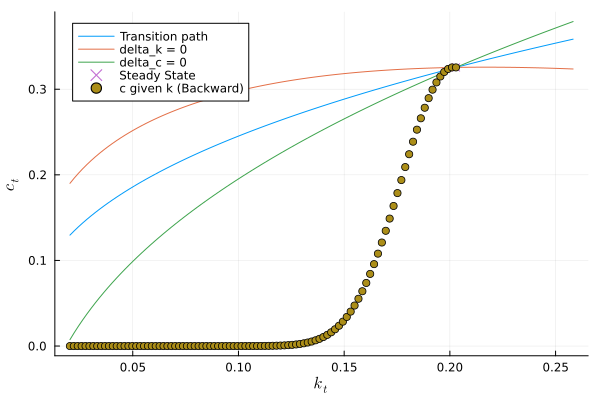

In [12]:
# plot(k2, c2, seriestype=:scatter)
# plot(k2, c2, seriestype=:scatter, zcolor = collect(1:length(k2)), color = :blues, colorbar=false, label="c0 too big")
# plot!(k3, c3, seriestype=:scatter, zcolor = collect(1:length(k2)), color = :reds, colorbar=false, label="c0 too small")
# plot!(k4, c4, seriestype=:scatter, zcolor = collect(1:length(k2)), color = :greens, colorbar=false, label="c0 on transition path")
plot(k0_list, c0_list, label="Transition path")
plot!(k0_list, k0_list.^alpha + (1 - delta) .* k0_list .- k0_list, label="delta_k = 0")
plot!(k0_list, cdot0_list, label="delta_c = 0")
plot!([kss], [css], seriestype=:scatter, m=:xcross, label="Steady State")
plot!(kvec0, cvec, seriestype=:scatter, label="c given k (Backward)")
xlabel!("\$k_t\$")
ylabel!("\$c_t\$")

In [13]:
kvec[1] = k0;
for j in 1:T-1
    kvec[j+1] = yvec[j] - cvec[j] + (1-m.delta)*kvec[j]; # k1,k2,...,kT
end


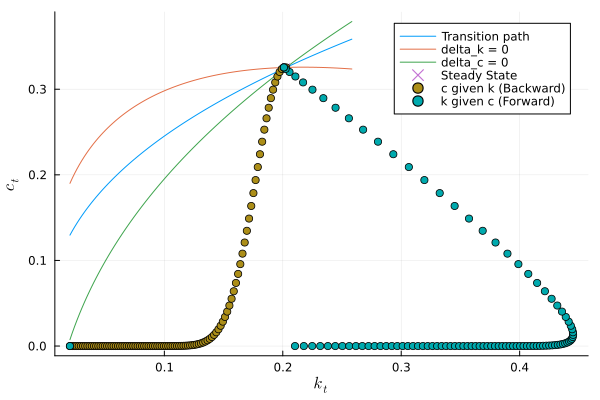

In [14]:
# plot(k2, c2, seriestype=:scatter)
# plot(k2, c2, seriestype=:scatter, zcolor = collect(1:length(k2)), color = :blues, colorbar=false, label="c0 too big")
# plot!(k3, c3, seriestype=:scatter, zcolor = collect(1:length(k2)), color = :reds, colorbar=false, label="c0 too small")
# plot!(k4, c4, seriestype=:scatter, zcolor = collect(1:length(k2)), color = :greens, colorbar=false, label="c0 on transition path")
plot(k0_list, c0_list, label="Transition path")
plot!(k0_list, k0_list.^alpha - (1 - delta) .* k0_list .- k0_list, label="delta_k = 0")
plot!(k0_list, cdot0_list, label="delta_c = 0")
plot!([kss], [css], seriestype=:scatter, m=:xcross, label="Steady State")
plot!(kvec0, cvec, seriestype=:scatter, label="c given k (Backward)")
plot!(kvec, cvec, seriestype=:scatter, label="k given c (Forward)")
xlabel!("\$k_t\$")
ylabel!("\$c_t\$")

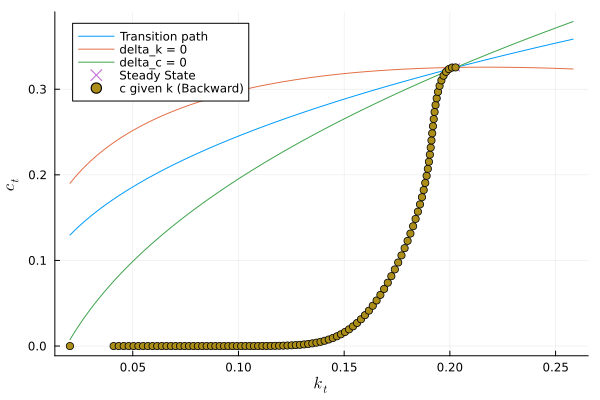

In [15]:
# update
kvec1 = lamk*kvec0 + (1-lamk)*kvec;

diff = maximum(abs.(kvec1-kvec0));
kvec0 = copy(kvec1);
iter += 1;

yvec .= m.Abar .* (kvec0 .^ m.alpha);
rvec .= m.alpha .* yvec./kvec0;
wvec .= (1-m.alpha) .* yvec;

cvec[m.T] = css;
for i in T-1:-1:1 # t=T-1,...,1,0
    cvec[i] = cvec[i+1]/(beta*(1+rvec[i+1]-delta));
end

# plot(k2, c2, seriestype=:scatter)
# plot(k2, c2, seriestype=:scatter, zcolor = collect(1:length(k2)), color = :blues, colorbar=false, label="c0 too big")
# plot!(k3, c3, seriestype=:scatter, zcolor = collect(1:length(k2)), color = :reds, colorbar=false, label="c0 too small")
# plot!(k4, c4, seriestype=:scatter, zcolor = collect(1:length(k2)), color = :greens, colorbar=false, label="c0 on transition path")
plot(k0_list, c0_list, label="Transition path")
plot!(k0_list, k0_list.^alpha - (1 - delta) .* k0_list .- k0_list, label="delta_k = 0")
plot!(k0_list, cdot0_list, label="delta_c = 0")
plot!([kss], [css], seriestype=:scatter, m=:xcross, label="Steady State")
plot!(kvec0, cvec, seriestype=:scatter, label="c given k (Backward)")
xlabel!("\$k_t\$")
ylabel!("\$c_t\$")

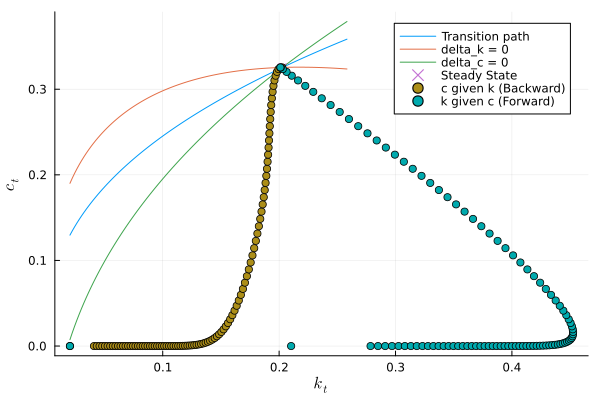

In [16]:
kvec[1] = k0;
for j in 1:T-1
    kvec[j+1] = yvec[j] - cvec[j] + (1-m.delta)*kvec[j]; # k1,k2,...,kT
end

# plot(k2, c2, seriestype=:scatter)
# plot(k2, c2, seriestype=:scatter, zcolor = collect(1:length(k2)), color = :blues, colorbar=false, label="c0 too big")
# plot!(k3, c3, seriestype=:scatter, zcolor = collect(1:length(k2)), color = :reds, colorbar=false, label="c0 too small")
# plot!(k4, c4, seriestype=:scatter, zcolor = collect(1:length(k2)), color = :greens, colorbar=false, label="c0 on transition path")
plot(k0_list, c0_list, label="Transition path")
plot!(k0_list, k0_list.^alpha - (1 - delta) .* k0_list .- k0_list, label="delta_k = 0")
plot!(k0_list, cdot0_list, label="delta_c = 0")
plot!([kss], [css], seriestype=:scatter, m=:xcross, label="Steady State")
plot!(kvec0, cvec, seriestype=:scatter, label="c given k (Backward)")
plot!(kvec, cvec, seriestype=:scatter, label="k given c (Forward)")
xlabel!("\$k_t\$")
ylabel!("\$c_t\$")

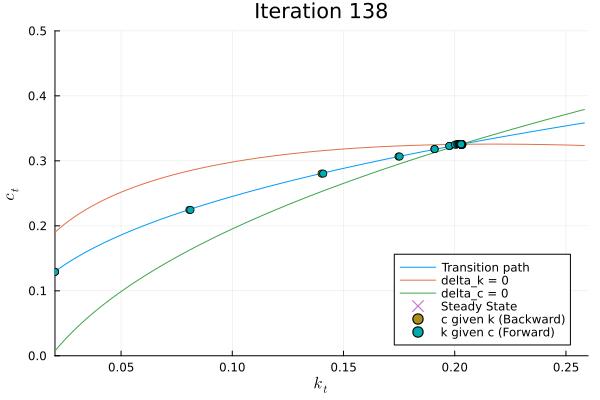

In [21]:
m = Model(alpha,beta,delta,Abar,kss,css,T);

# imaginary states
kvec0 = collect(range(k0,m.kss,m.T));
kvec1 = copy(kvec0);
yvec = zeros(m.T);
rvec = zeros(m.T);
wvec = zeros(m.T);
cvec = zeros(m.T);
kvec = zeros(m.T);

lamk = 0.9;
diff = 1e+4;
crit = 1e-4;
iter = 0;

anim = Animation()

while diff > crit
    yvec .= m.Abar .* (kvec0 .^ m.alpha);
    rvec .= m.alpha .* yvec./kvec0;
    wvec .= (1-m.alpha) .* yvec;
    
    cvec[m.T] = css;
    for i in T-1:-1:1 # t=T-1,...,1,0
        cvec[i] = cvec[i+1]/(beta*(1+rvec[i+1]-delta));
    end

    kvec[1] = k0;
    for j in 1:T-1
        kvec[j+1] = yvec[j] - cvec[j] + (1-m.delta)*kvec[j]; # k1,k2,...,kT
    end

    # update
    kvec1 = lamk*kvec0 + (1-lamk)*kvec;

    diff = maximum(abs.(kvec1-kvec0));
    kvec0 = copy(kvec1);
    iter += 1;
    
#     if iter % 20 == 0
    current_plot = plot(k0_list, c0_list, label="Transition path", title="Iteration $iter", legend=:bottomright)
    plot!(k0_list, k0_list.^alpha - (1 - delta) .* k0_list .- k0_list, label="delta_k = 0")
    plot!(k0_list, cdot0_list, label="delta_c = 0")
    plot!([kss], [css], seriestype=:scatter, m=:xcross, label="Steady State")
    plot!(kvec0, cvec, seriestype=:scatter, label="c given k (Backward)")
    plot!(kvec, cvec, seriestype=:scatter, label="k given c (Forward)")
    xlabel!("\$k_t\$")
    ylabel!("\$c_t\$")
    plot!(ylims=(0, 0.5))
    plot!(xlims=(k0, 0.26))
    
    display(current_plot)
    sleep(0.04)
    frame(anim)
#     end
    IJulia.clear_output(true)
    # use the terminal condition as the criterion
#     println([iter, diff])
#     flush(stdout)
end

In [18]:
# gif(anim, "lol.gif", fps=10);

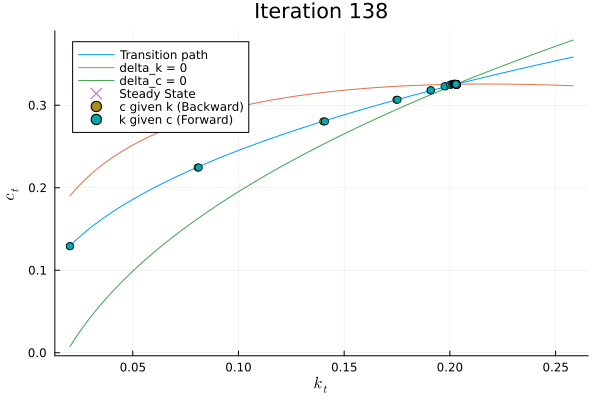

In [18]:
plot(k0_list, c0_list, label="Transition path", title="Iteration $iter")
plot!(k0_list, k0_list.^alpha - (1 - delta) .* k0_list .- k0_list, label="delta_k = 0")
plot!(k0_list, cdot0_list, label="delta_c = 0")
plot!([kss], [css], seriestype=:scatter, m=:xcross, label="Steady State")
plot!(kvec0, cvec, seriestype=:scatter, label="c given k (Backward)")
plot!(kvec, cvec, seriestype=:scatter, label="k given c (Forward)")
xlabel!("\$k_t\$")
ylabel!("\$c_t\$")